['AGE_AT_DOS_BX', 'CSTAGE', 'PSTAGE', 'CIGARETTE_HX_Never', 'NEOADJUVANT_Yes', 'RACE_Black', 'RACE_Other', 'RACE_White', 'SEX_Male', 'PREDOM_HISTO_SUBTYPE_Lepidic', 'PREDOM_HISTO_SUBTYPE_Micropapillary', 'PREDOM_HISTO_SUBTYPE_Papillary', 'PREDOM_HISTO_SUBTYPE_Solid', 'PREDOM_HISTO_SUBTYPE_Unknown', 'PRE_SAMPLE_CHEMOTHERAPY_Yes', 'PRE_SAMPLE_IMMUNOTHERAPY_Yes', 'PRE_SAMPLE_TARGETED_Yes', 'PRE_SAMPLE_TX_Yes', 'PRE_SAMPLE_XRT_Yes', 'ALK', 'APC', 'ARID1A', 'ATM', 'BRAF', 'BRCA1', 'BRCA2', 'CDKN2A', 'CTNNB1', 'EGFR', 'ERBB2', 'FGFR1', 'KEAP1', 'KRAS', 'MAP2K1', 'MET', 'MTOR', 'NF1', 'NOTCH1', 'NOTCH2', 'NTRK1', 'NTRK2', 'NTRK3', 'PIK3CA', 'PTEN', 'RB1', 'RBM10', 'RET', 'ROS1', 'SETD2', 'SMAD4', 'SMARCA4', 'STK11', 'TERT', 'TP53', 'TSC1', 'TSC2', 'U2AF1', 'FGA', 'FRACTION_GENOME_ALTERED', 'MSI_SCORE', 'MUTATION_COUNT', 'PLOIDY', 'PURITY', 'TMB_NONSYNONYMOUS', 'CELL_CYCLE_Yes', 'IS_WGD_1', 'MSI_TYPE_Indeterminate', 'MSI_TYPE_Instable', 'MSI_TYPE_Stable', 'TP53_x_EGFR', 'KEAP1_x_STK11', 'KEAP1

IndexError: list index out of range

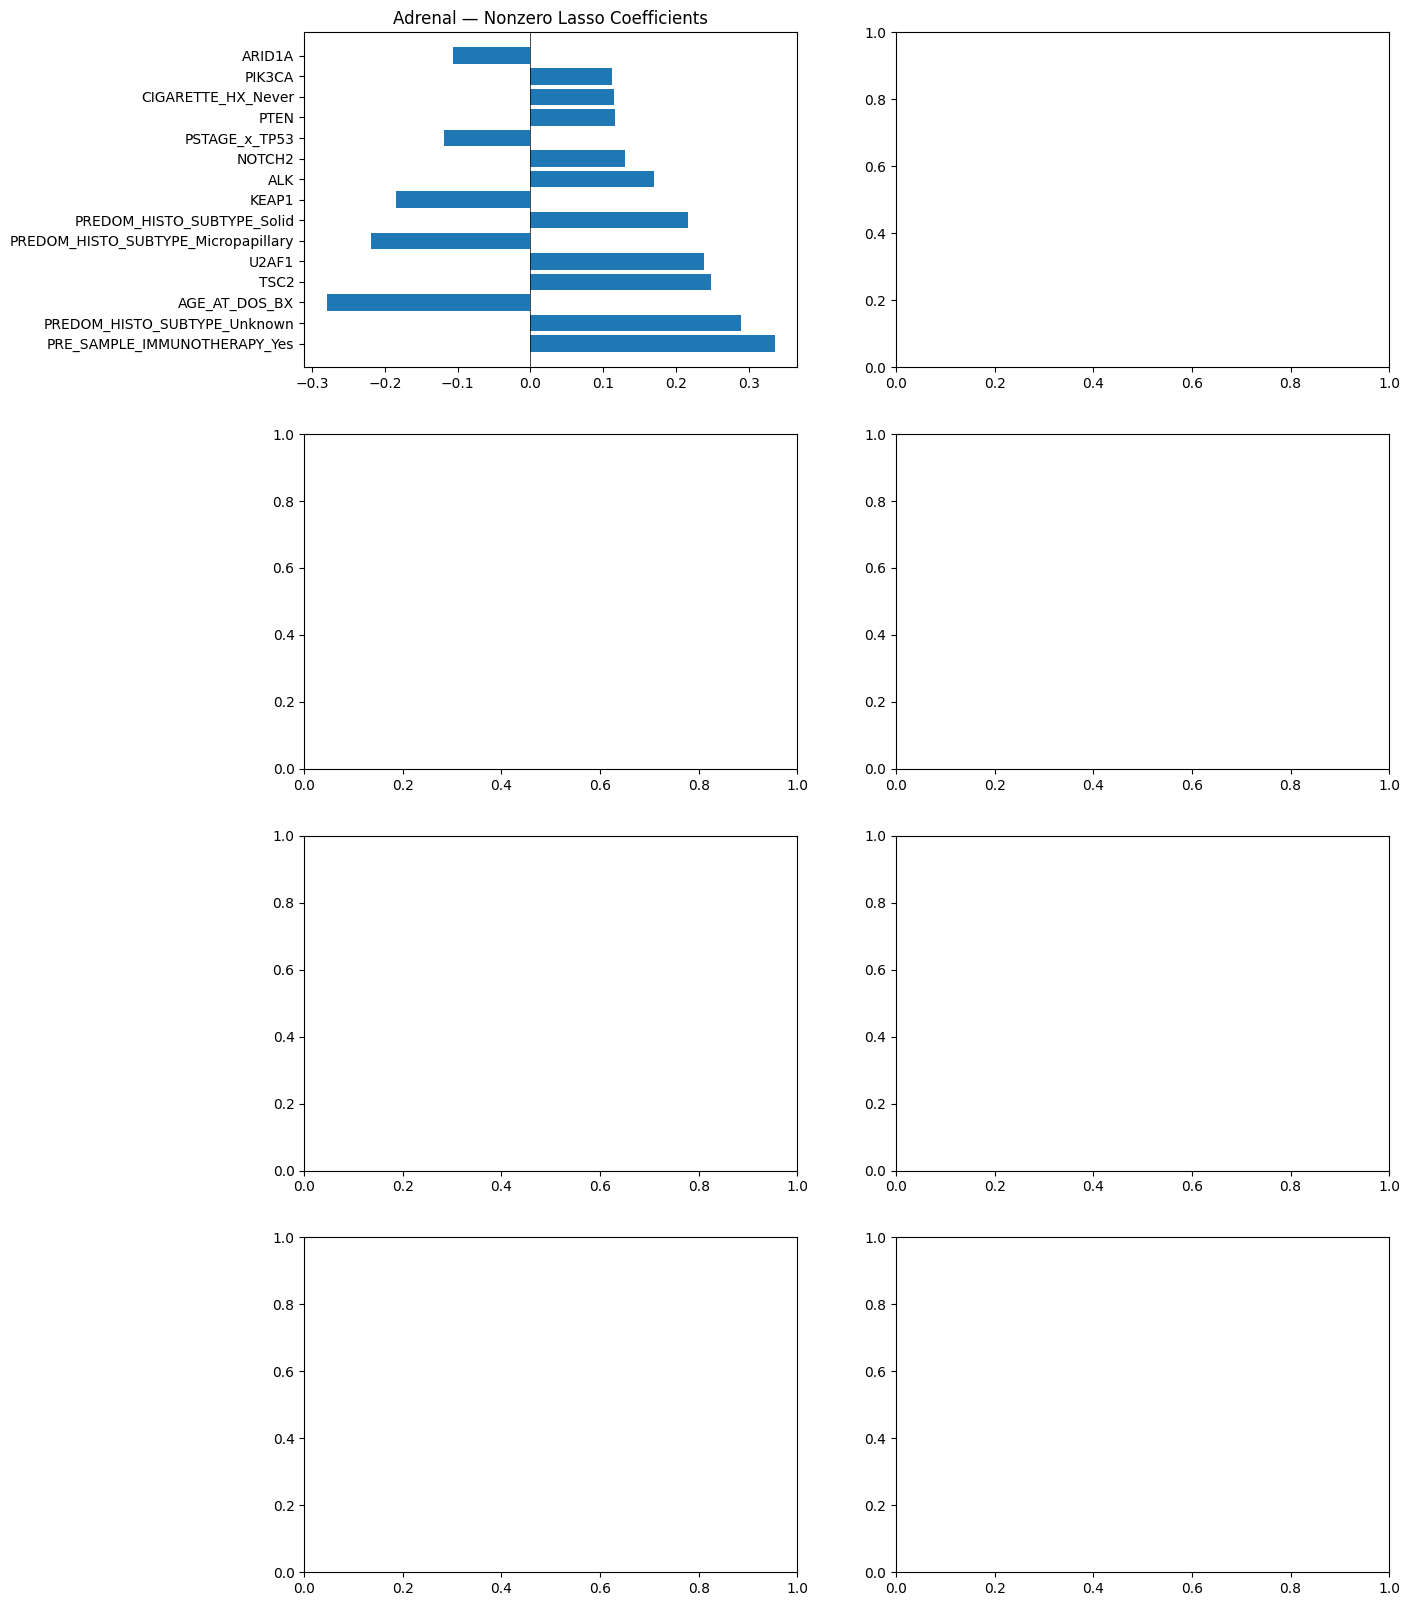

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd

# load fitted lasso model
lasso = joblib.load('../models/fitted_models/combined_interact/multilabel/logistic_lasso_combined_interact.pkl')

# get feature names
X = pd.read_csv('../data/processed/X_combined_interact.csv')
id_cols = ['Unnamed: 0', 'patientId', 'sampleId', 'GENE_PANEL']
X = X.drop(columns=[c for c in id_cols if c in X.columns])
feature_names = X.columns.tolist()
print(feature_names)

# extract coefficients - ClassifierChain has estimators_ attribute
label_names = ['Adrenal', 'Bone', 'CNS', 'Liver', 'LN', 'Lung', 'Pleura']

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, (estimator, label) in enumerate(zip(lasso.estimators_, label_names)):
    coef = estimator.coef_[0]
    nonzero_mask = coef != 0
    nonzero_features = [feature_names[j] for j in range(len(coef)) if nonzero_mask[j]]
    nonzero_coefs = coef[nonzero_mask]
    
    # sort by magnitude
    sorted_idx = np.argsort(np.abs(nonzero_coefs))[::-1][:15]  # top 15
    
    axes[i].barh(range(len(sorted_idx)), nonzero_coefs[sorted_idx])
    axes[i].set_yticks(range(len(sorted_idx)))
    axes[i].set_yticklabels([nonzero_features[j] for j in sorted_idx])
    axes[i].set_title(f'{label} — Nonzero Lasso Coefficients')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('results/figures/lasso_coefficients.png', dpi=150, bbox_inches='tight')


Saved


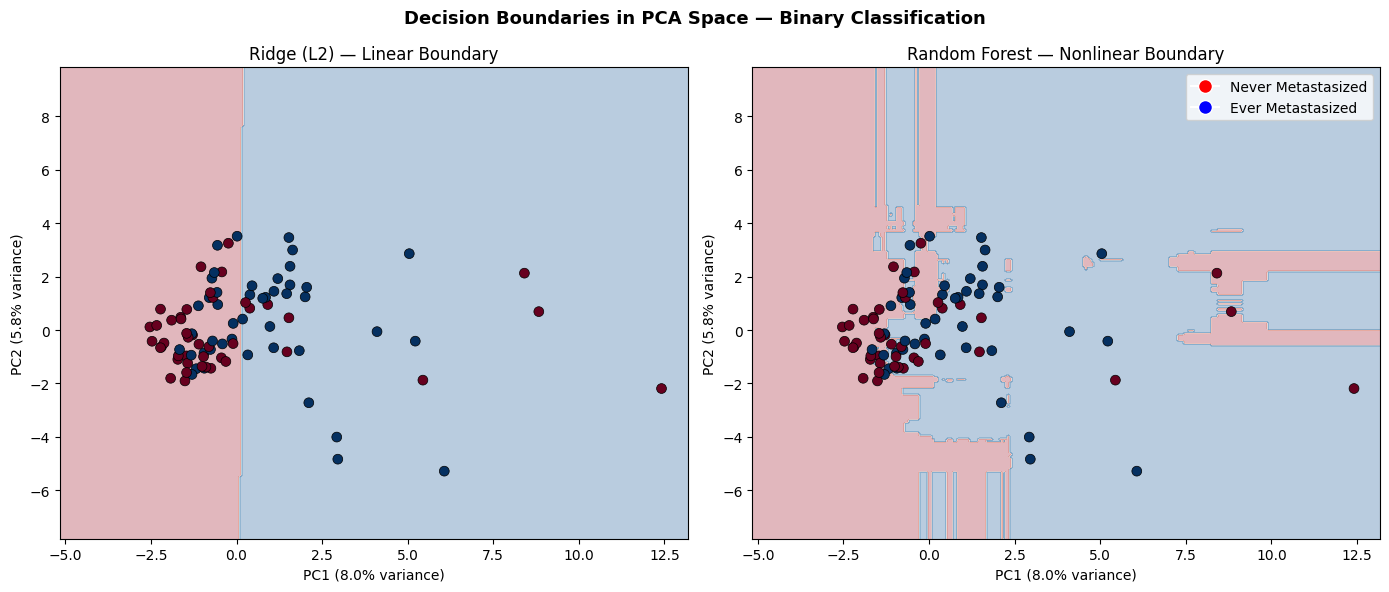

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import joblib
from utils.model_utils import load_train_test

# Load binary combined data
X_train, X_test, y_train, y_test = load_train_test(
    '../data/processed/X_combined.csv',
    '../data/processed/y_binary.csv',
    scale=True
)
y_train = y_train.ravel()
y_test = y_test.ravel()

# Load actual fitted models
ridge = joblib.load('../models/fitted_models/combined/binary/logistic_ridge_combined.pkl')
rf = joblib.load('../models/fitted_models/combined/binary/random_forest_combined.pkl')

# PCA to 2D — fit on training data only
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Refit loaded models on 2D PCA features
ridge_2d = ridge.__class__(**ridge.get_params())
rf_2d = rf.__class__(**rf.get_params())
ridge_2d.fit(X_train_2d, y_train)
rf_2d.fit(X_train_2d, y_train)

# Mesh grid
x_min, x_max = X_train_2d[:, 0].min() - 2, X_train_2d[:, 0].max() + 2
y_min, y_max = X_train_2d[:, 1].min() - 2, X_train_2d[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_2d, title in zip(axes,
                                [ridge_2d, rf_2d],
                                ['Ridge (L2) — Linear Boundary',
                                 'Random Forest — Nonlinear Boundary']):
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                        c=y_test, cmap='RdBu', edgecolors='k',
                        linewidth=0.5, s=50)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

# discrete legend instead of colorbar
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                          markersize=10, label='Never Metastasized'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                          markersize=10, label='Ever Metastasized')]
axes[1].legend(handles=legend_elements, loc='upper right')

plt.suptitle('Decision Boundaries in PCA Space — Binary Classification',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/other/decision_boundary_pca.png', dpi=150, bbox_inches='tight')
print("Saved")
